<a href="https://www.kaggle.com/code/sonawanelalitsunil/heart-disease-2025-3-000-records-ml-59-44?scriptVersionId=257433314" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease-dataset-3k-rows-python-code-2025/heart_disease_dataset.xlsx
/kaggle/input/heart-disease-dataset-3k-rows-python-code-2025/heart_disease_dataset.csv
/kaggle/input/heart-disease-dataset-3k-rows-python-code-2025/heart_disease_dataset.json


## Title: 
Heart Disease Dataset 2025 (3,000 Records)

## Description:
This dataset contains 3,000 patient health records collected in 2025, focusing on clinical, lifestyle, and demographic factors related to heart disease. It includes attributes such as age, gender, blood pressure, cholesterol levels, BMI, glucose, smoking and alcohol habits, family history, physical activity, and medical history. The dataset is designed for predictive analytics, risk assessment, and machine learning tasks such as classification and survival analysis. It can be used to build models that identify high-risk patients, explore correlations between lifestyle factors and heart health, and evaluate early intervention strategies for cardiovascular disease prevention.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/heart-disease-dataset-3k-rows-python-code-2025/heart_disease_dataset.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
0,67,1,2,111,536,0,2,88,0,1.3,3,2,3,1,0,23.4,0
1,57,1,3,109,107,0,2,119,0,5.4,2,0,3,0,1,35.4,0
2,43,1,4,171,508,0,1,113,0,3.7,3,0,7,1,1,29.9,0
3,71,0,4,90,523,0,2,152,0,4.7,2,1,3,1,0,15.2,1
4,36,1,2,119,131,0,2,128,0,5.9,3,1,3,1,0,16.7,1


In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
3064,52,0,1,169,479,0,0,124,0,3.7,2,3,3,0,0,27.8,0
3065,75,0,4,90,372,0,2,141,0,2.1,2,2,3,0,1,37.0,1
3066,68,1,4,166,564,0,1,76,0,4.5,3,1,3,0,0,16.1,0
3067,66,0,3,143,113,1,1,207,0,3.6,1,0,6,0,0,27.7,0
3068,38,1,4,100,507,0,1,187,0,0.9,1,0,7,0,0,16.3,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3069 entries, 0 to 3068
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            3069 non-null   int64  
 1   sex            3069 non-null   int64  
 2   cp             3069 non-null   int64  
 3   trestbps       3069 non-null   int64  
 4   chol           3069 non-null   int64  
 5   fbs            3069 non-null   int64  
 6   restecg        3069 non-null   int64  
 7   thalach        3069 non-null   int64  
 8   exang          3069 non-null   int64  
 9   oldpeak        3069 non-null   float64
 10  slope          3069 non-null   int64  
 11  ca             3069 non-null   int64  
 12  thal           3069 non-null   int64  
 13  smoking        3069 non-null   int64  
 14  diabetes       3069 non-null   int64  
 15  bmi            3069 non-null   float64
 16  heart_disease  3069 non-null   int64  
dtypes: float64(2), int64(15)
memory usage: 407.7 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
count,3069.00000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000
mean,52.50114,0.555556,2.489736,145.306289,347.219941,0.145650,1.004236,135.157380,0.176279,3.189052,2.023786,0.626588,4.544477,0.348974,0.193874,27.496839,0.403715
std,13.70752,0.496985,1.110417,31.602321,146.853319,0.352813,0.812016,43.353197,0.381119,1.802815,0.817679,0.891447,1.751064,0.476723,0.395396,7.281731,0.490721
min,29.00000,0.000000,1.000000,90.000000,100.000000,0.000000,0.000000,60.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,15.000000,0.000000
25%,41.00000,0.000000,2.000000,118.000000,215.000000,0.000000,0.000000,98.000000,0.000000,1.600000,1.000000,0.000000,3.000000,0.000000,0.000000,21.300000,0.000000
50%,53.00000,1.000000,2.000000,146.000000,350.000000,0.000000,1.000000,135.000000,0.000000,3.200000,2.000000,0.000000,3.000000,0.000000,0.000000,27.400000,0.000000
75%,64.00000,1.000000,3.000000,172.000000,475.000000,0.000000,2.000000,172.000000,0.000000,4.700000,3.000000,1.000000,6.000000,1.000000,0.000000,33.900000,1.000000
max,76.00000,1.000000,4.000000,200.000000,600.000000,1.000000,2.000000,210.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000,1.000000,40.000000,1.000000


In [7]:
df.isnull().sum()

age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               0
thal             0
smoking          0
diabetes         0
bmi              0
heart_disease    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(3069, 17)

In [10]:
df.dtypes

age                int64
sex                int64
cp                 int64
trestbps           int64
chol               int64
fbs                int64
restecg            int64
thalach            int64
exang              int64
oldpeak          float64
slope              int64
ca                 int64
thal               int64
smoking            int64
diabetes           int64
bmi              float64
heart_disease      int64
dtype: object

In [11]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'smoking', 'diabetes', 'bmi',
       'heart_disease'],
      dtype='object')

## Data visualizations

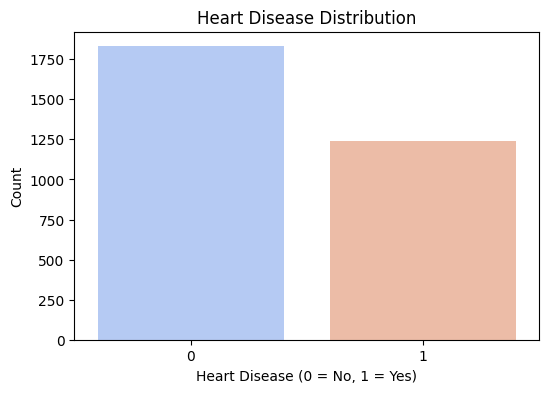

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="heart_disease", palette="coolwarm")
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


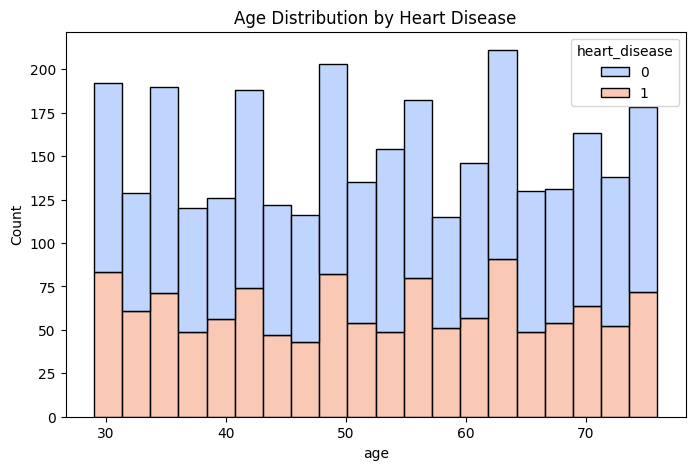

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="heart_disease", multiple="stack", bins=20, palette="coolwarm")
plt.title("Age Distribution by Heart Disease")
plt.show()

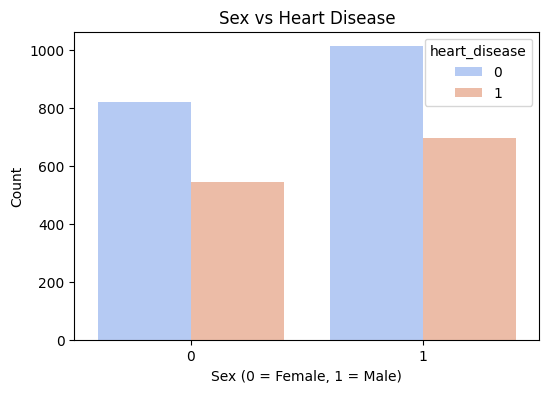

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sex", hue="heart_disease", palette="coolwarm")
plt.title("Sex vs Heart Disease")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()

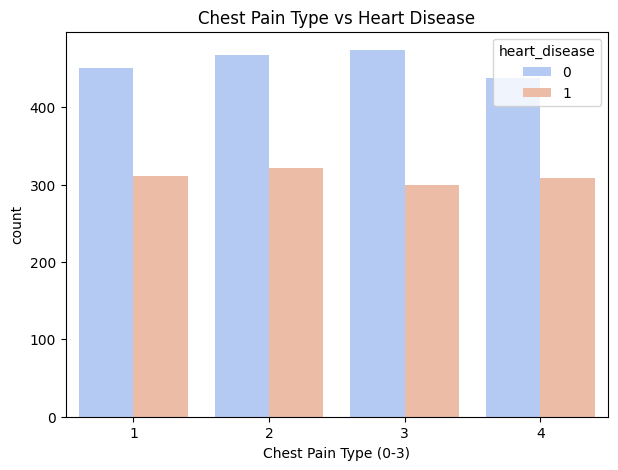

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="cp", hue="heart_disease", palette="coolwarm")
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type (0-3)")
plt.show()

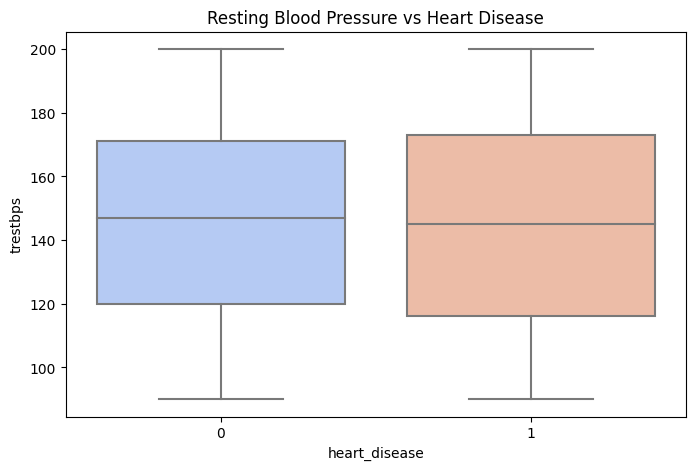

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="heart_disease", y="trestbps", palette="coolwarm")
plt.title("Resting Blood Pressure vs Heart Disease")
plt.show()

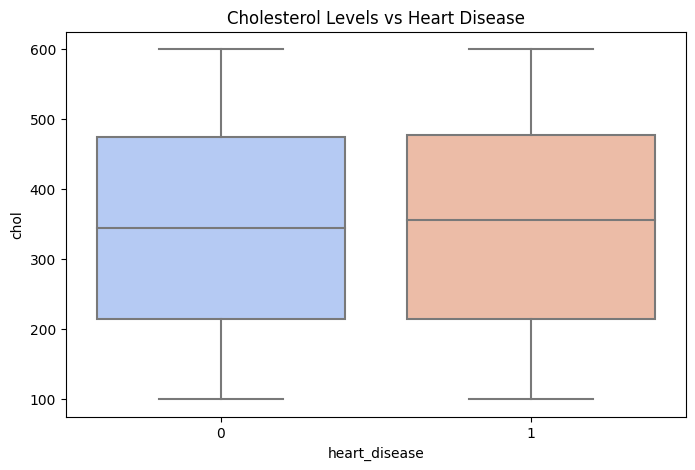

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="heart_disease", y="chol", palette="coolwarm")
plt.title("Cholesterol Levels vs Heart Disease")
plt.show()

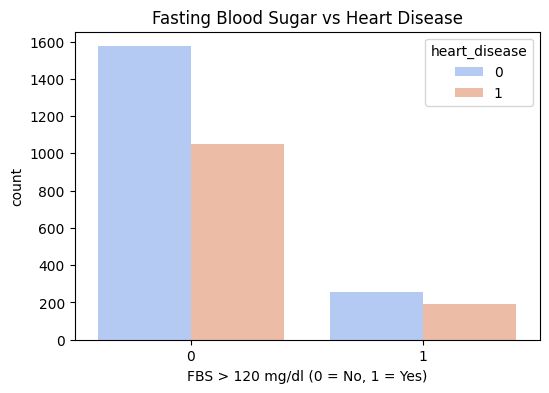

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="fbs", hue="heart_disease", palette="coolwarm")
plt.title("Fasting Blood Sugar vs Heart Disease")
plt.xlabel("FBS > 120 mg/dl (0 = No, 1 = Yes)")
plt.show()


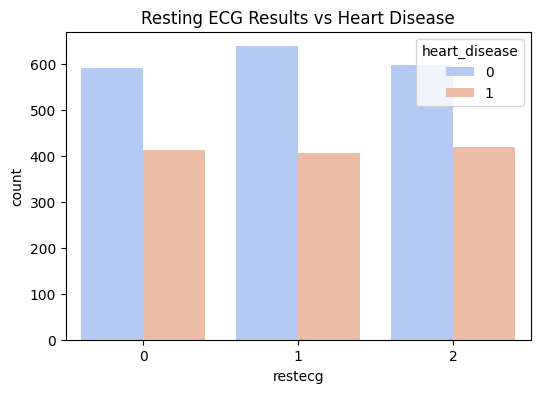

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="restecg", hue="heart_disease", palette="coolwarm")
plt.title("Resting ECG Results vs Heart Disease")
plt.show()

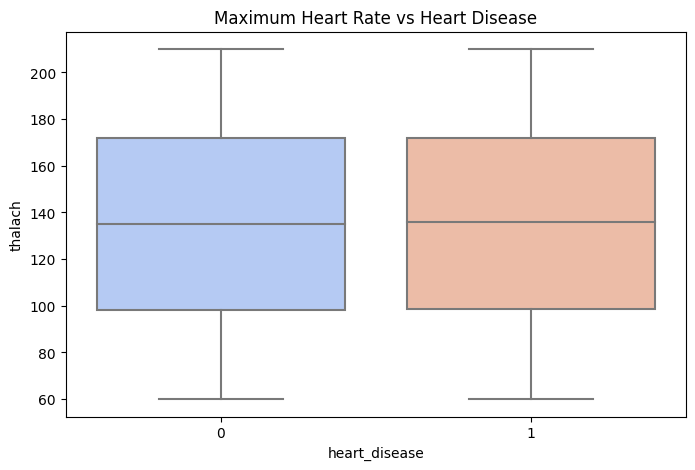

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="heart_disease", y="thalach", palette="coolwarm")
plt.title("Maximum Heart Rate vs Heart Disease")
plt.show()

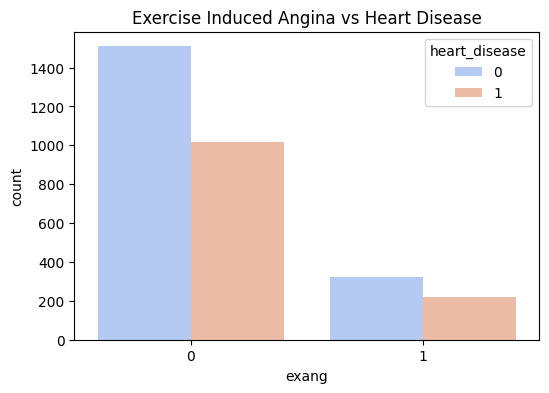

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="exang", hue="heart_disease", palette="coolwarm")
plt.title("Exercise Induced Angina vs Heart Disease")
plt.show()

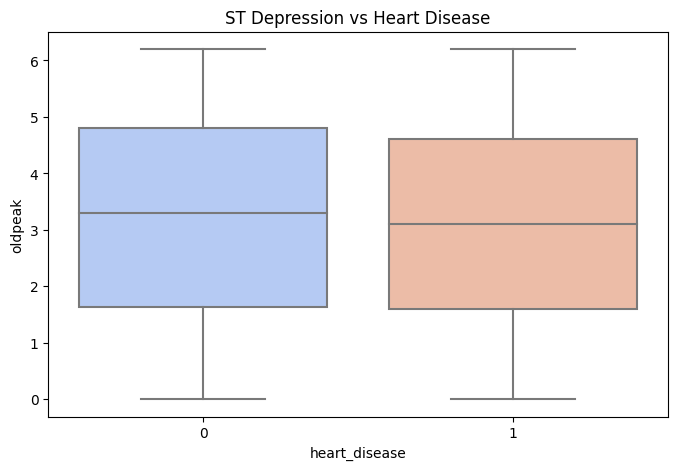

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="heart_disease", y="oldpeak", palette="coolwarm")
plt.title("ST Depression vs Heart Disease")
plt.show()

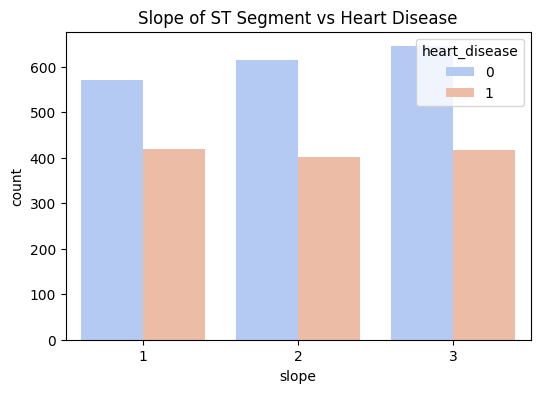

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="slope", hue="heart_disease", palette="coolwarm")
plt.title("Slope of ST Segment vs Heart Disease")
plt.show()

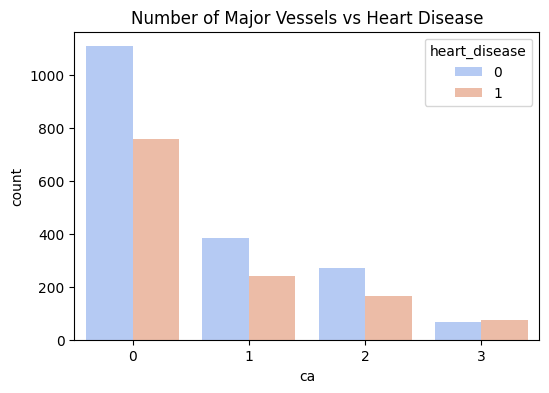

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="ca", hue="heart_disease", palette="coolwarm")
plt.title("Number of Major Vessels vs Heart Disease")
plt.show()

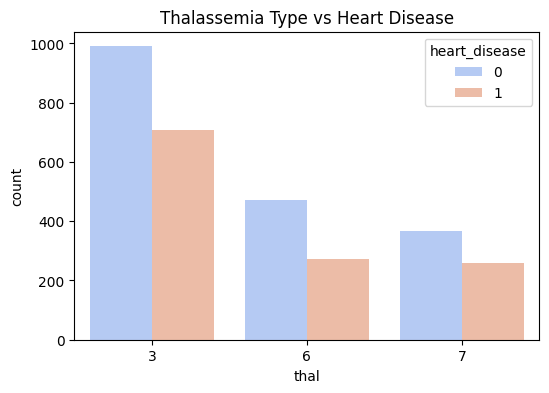

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="thal", hue="heart_disease", palette="coolwarm")
plt.title("Thalassemia Type vs Heart Disease")
plt.show()


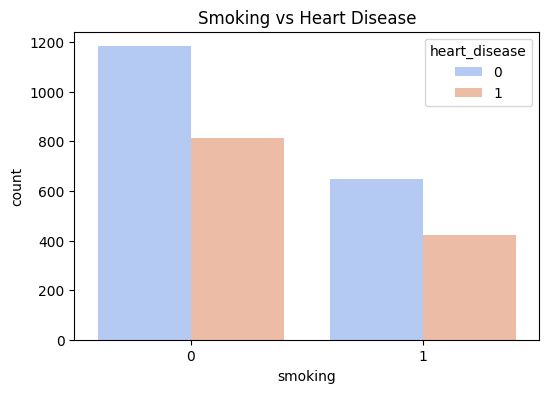

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="smoking", hue="heart_disease", palette="coolwarm")
plt.title("Smoking vs Heart Disease")
plt.show()


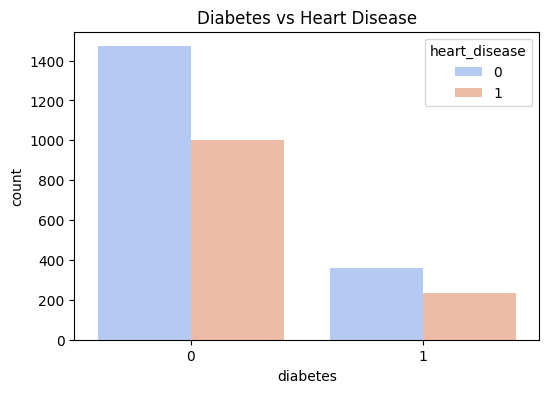

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="diabetes", hue="heart_disease", palette="coolwarm")
plt.title("Diabetes vs Heart Disease")
plt.show()


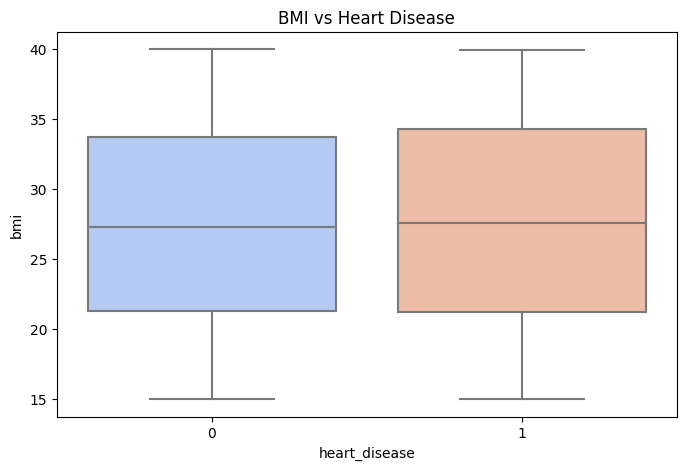

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="heart_disease", y="bmi", palette="coolwarm")
plt.title("BMI vs Heart Disease")
plt.show()


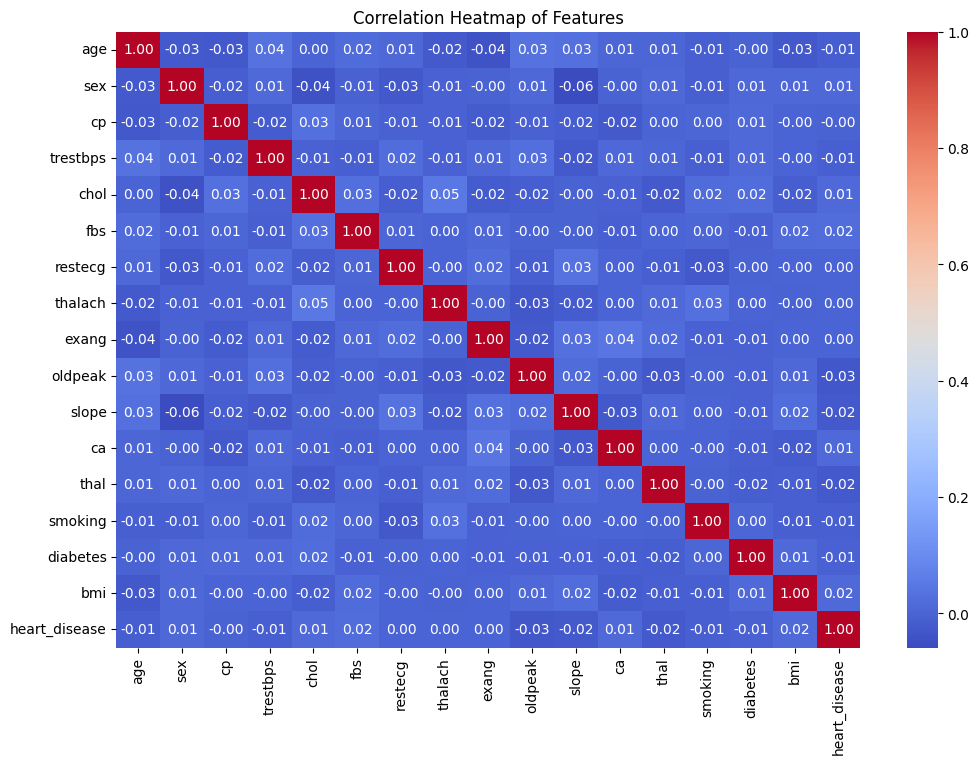

In [29]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()

## Predictive modeling

In [30]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

In [31]:
cat_cols = ['sex','cp','restecg','slope','ca','thal','smoking','diabetes']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


In [32]:
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [34]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc

In [35]:
results_df = pd.DataFrame(list(results.items()), columns=["Algorithm", "Accuracy (%)"])
print(results_df)

             Algorithm  Accuracy (%)
0  Logistic Regression     59.446254
1        Decision Tree     52.442997
2        Random Forest     56.188925
3    Gradient Boosting     56.677524
4                  KNN     54.234528
5                  SVM     59.609121
6              XGBoost     52.605863


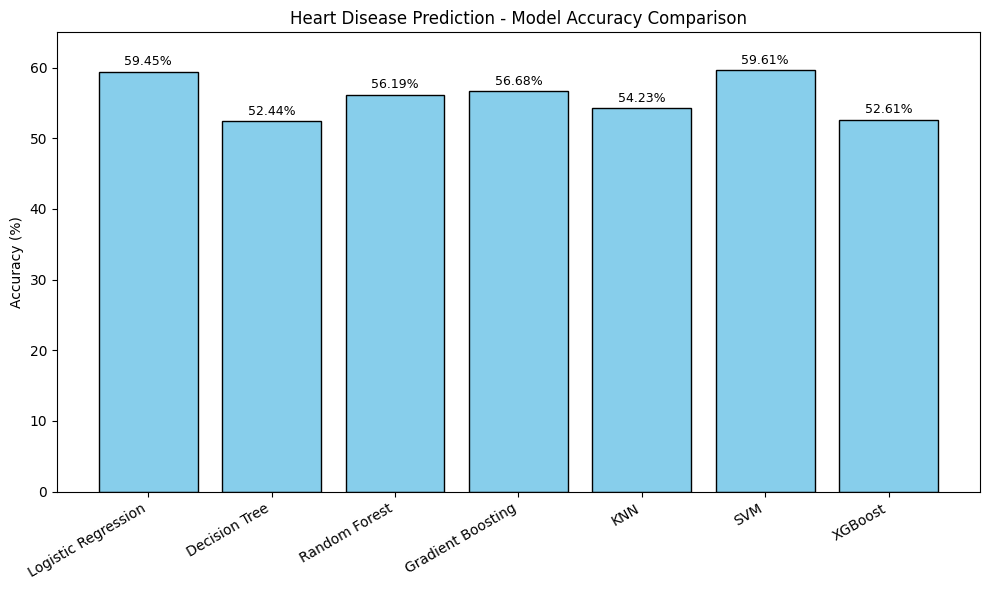

In [36]:
# Accuracy results
results_df = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression", "Decision Tree", "Random Forest", 
        "Gradient Boosting", "KNN", "SVM", "XGBoost"
    ],
    "Accuracy (%)": [
        59.446254, 52.442997, 56.188925, 
        56.677524, 54.234528, 59.609121, 52.605863
    ]
})

# Bar plot
plt.figure(figsize=(10,6))
bars = plt.bar(results_df["Algorithm"], results_df["Accuracy (%)"], 
               color="skyblue", edgecolor="black")

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}%", 
             ha='center', va='bottom', fontsize=9)

plt.title("Heart Disease Prediction - Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 65)
plt.tight_layout()
plt.show()

## Thank you..pls upvote!!!!